# Dependências

In [34]:
import os
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Carregamento dos Dados

In [35]:
DATA_DIR = "../data"
ZIP_NAME = "ocorrencias_aviacao_civil_br.zip"
EXTRACT_DIR = "ocorrencias_aviacao_civil_br"
CSV_NAME = "ocorrencias_aviacao_civil_br.csv"

ZIP_PATH = os.path.join(DATA_DIR, ZIP_NAME)
CSV_PATH = os.path.join(DATA_DIR, EXTRACT_DIR, CSV_NAME)

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"Dataset not found at '{ZIP_PATH}'. Place the zip file there and rerun.")

if not os.path.exists(CSV_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)

df = pd.read_csv(CSV_PATH)


# Análise Exploratória Inicial

In [36]:
df.head()

,codigo_ocorrencia,ocorrencia_classificacao,ocorrencia_tipo,ocorrencia_tipo_categoria,ocorrencia_tipo_icao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,ocorrencia_pais,...,ocorrencia_horario,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista,ocorrencia_dia_extracao
0,201305055424986,ACIDENTE,FALHA DO MOTOR EM VOO,FALHA OU MAU FUNCIONAMENTO DO MOTOR,SCF-PP,-9.9085,-63.0333,ARIQUEMES,RO,BRASIL,...,11:00:00,NaN,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28
1,201605160250139,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,CTOL,-11.2644,-61.2589,CACOAL,RO,BRASIL,...,19:19:00,SIM,ATIVA,IG-084/CENIPA/2016,NÃO,NaN,0,1,NÃO,2018-08-28
2,201805021421302,INCIDENTE,AERÓDROMO,AERÓDROMO,ADRM,-11.4956,-61.4508,CACOAL,RO,BRASIL,...,22:40:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28
3,201311259977425,INCIDENTE GRAVE,POUSO SEM TREM,CONTATO ANORMAL COM A PISTA,ARC,-11.4956,-61.4508,CACOAL,RO,BRASIL,...,12:32:00,NaN,FINALIZADA,IG-209/CENIPA/2013,SIM,2014-04-07,0,1,NÃO,2018-08-28
4,201103187273112,INCIDENTE,OUTROS,OUTROS,OTHR,-13.1950,-60.8184,CEREJEIRAS,RO,BRASIL,...,13:30:00,NaN,FINALIZADA,***,NÃO,NaN,0,1,NÃO,2018-08-28


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   codigo_ocorrencia               5208 non-null   int64  
 1   ocorrencia_classificacao        5208 non-null   str    
 2   ocorrencia_tipo                 5208 non-null   str    
 3   ocorrencia_tipo_categoria       5208 non-null   str    
 4   ocorrencia_tipo_icao            5208 non-null   str    
 5   ocorrencia_latitude             5208 non-null   float64
 6   ocorrencia_longitude            5208 non-null   float64
 7   ocorrencia_cidade               5208 non-null   str    
 8   ocorrencia_uf                   5208 non-null   str    
 9   ocorrencia_pais                 5208 non-null   str    
 10  ocorrencia_aerodromo            5208 non-null   str    
 11  ocorrencia_dia                  5208 non-null   str    
 12  ocorrencia_horario              5208 non-null

In [38]:
print("Verificando valores nulos no DataFrame:")
print(df.isnull().sum())

Verificando valores nulos no DataFrame:
codigo_ocorrencia                    0
ocorrencia_classificacao             0
ocorrencia_tipo                      0
ocorrencia_tipo_categoria            0
ocorrencia_tipo_icao                 0
ocorrencia_latitude                  0
ocorrencia_longitude                 0
ocorrencia_cidade                    0
ocorrencia_uf                        0
ocorrencia_pais                      0
ocorrencia_aerodromo                 0
ocorrencia_dia                       0
ocorrencia_horario                   0
investigacao_aeronave_liberada    4098
investigacao_status                  0
divulgacao_relatorio_numero          0
divulgacao_relatorio_publicado       0
divulgacao_dia_publicacao         3947
total_recomendacoes                  0
total_aeronaves_envolvidas           0
ocorrencia_saida_pista               0
ocorrencia_dia_extracao              0
dtype: int64


#### Valores nulos
As únicas colunas com valores nulos são `investigacao_aeronave_liberada` (4.098 nulos) e `divulgacao_dia_publicacao` (3.947 nulos). Ambas serão descartadas, não por causa dos nulos em si, mas porque não têm valor preditivo para o objetivo do modelo.

In [39]:
print("Valores únicos em 'ocorrencia_tipo_categoria':")
print(df['ocorrencia_tipo_categoria'].unique())

Valores únicos em 'ocorrencia_tipo_categoria':
<StringArray>
[                'FALHA OU MAU FUNCIONAMENTO DO MOTOR',
   'COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO',
                                           'AERÓDROMO',
                         'CONTATO ANORMAL COM A PISTA',
                                              'OUTROS',
                           'PERDA DE CONTROLE NO SOLO',
                                   'EXCURSÃO DE PISTA',
                 'PERDA DE SEPARAÇÃO / COLISÃO EM VOO',
                            'PERDA DE CONTROLE EM VOO',
  'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE',
                                       'INDETERMINADO',
                     'VOO CONTROLADO CONTRA O TERRENO',
                                   'INCURSÃO EM PISTA',
 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE ',
                           'POUSO AQUÉM/ALÉM DA PISTA',
                                              'MÉDICO',
                                     'COLIS

### Decisões baseadas na análise exploratória

#### Colunas descartadas
| Coluna | Motivo |
|---|---|
| `codigo_ocorrencia` | Identificador único, sem valor preditivo |
| `ocorrencia_tipo` | Risco de data leakage — descreve o mesmo evento que o target |
| `ocorrencia_tipo_icao` | Risco de data leakage — codificação do tipo de ocorrência |
| `ocorrencia_latitude` | Localização geográfica sem relação causal com o target |
| `ocorrencia_longitude` | Localização geográfica sem relação causal com o target |
| `ocorrencia_cidade` | Alta cardinalidade, substituída por `uf` |
| `ocorrencia_pais` | Coluna constante — todos os registros são `BRASIL` |
| `ocorrencia_aerodromo` | Alta cardinalidade, sem relação causal com o target |
| `investigacao_aeronave_liberada` | 4.098 nulos — descartada |
| `investigacao_status` | Dado posterior ao evento — status administrativo da investigação, não disponível no momento da ocorrência |
| `divulgacao_relatorio_numero` | Dado administrativo, sem valor preditivo |
| `divulgacao_relatorio_publicado` | Dado administrativo, sem valor preditivo |
| `divulgacao_dia_publicacao` | 3.947 nulos e posterior ao evento — descartada |
| `ocorrencia_dia_extracao` | Metadado do dataset, sem valor preditivo |
| `total_recomendacoes` | Descartada — dado posterior ao evento, gerado durante a investigação |

#### Colunas mantidas e transformações previstas
| Coluna original | Coluna resultante | Transformação |
|---|---|---|
| `ocorrencia_classificacao` | `classificacao` | Renomear + OneHotEncoder |
| `ocorrencia_uf` | `uf` | Renomear + OneHotEncoder |
| `ocorrencia_dia` | `mes_sin`, `mes_cos` | Extrair mês, aplicar codificação cíclica (seno e cosseno) e descartar original |
| `ocorrencia_horario` | `periodo_dia` | Mapear hora para Madrugada / Manhã / Tarde / Noite, descartar original e aplicar OneHotEncoder |
| `total_aeronaves_envolvidas` | `total_aeronaves` | Renomear |
| `ocorrencia_saida_pista` | `saida_pista` | Renomear + converter SIM/NÃO para 1/0 |
| `ocorrencia_tipo_categoria` | `fator_predominante` | Usada para criar o target e depois descartada |

#### Criação do target: `fator_predominante`
A coluna `ocorrencia_tipo_categoria` será usada para derivar o target do modelo. 
A classificação foi definida da seguinte forma:

**Humano:**
`PERDA DE CONTROLE EM VOO`, `PERDA DE CONTROLE NO SOLO`, `MANOBRA ABRUPTA`, 
`OPERAÇÃO A BAIXA ALTITUDE`, `MÉDICO`

**Técnico:**
`FALHA OU MAU FUNCIONAMENTO DO MOTOR`, 
`FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE`, 
`FOGO/FUMAÇA (SEM IMPACTO)`

**Outros (excluídos do treinamento):**
`COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO`, `AERÓDROMO`,
`CONTATO ANORMAL COM A PISTA`, `OUTROS`, `EXCURSÃO DE PISTA`,
`PERDA DE SEPARAÇÃO / COLISÃO EM VOO`, `INDETERMINADO`,
`VOO CONTROLADO CONTRA O TERRENO`, `INCURSÃO EM PISTA`,
`POUSO AQUÉM/ALÉM DA PISTA`, `COLISÃO NO SOLO`, `COMBUSTÍVEL`,
`TURBULÊNCIA`, `CORTANTE DE VENTO / TEMPESTADE`, `OPERAÇÕES NO SOLO`,
`RELACIONADO COM SECURITY`

Todas as categorias acima foram classificadas como `Outros` por serem ambíguas 
ou por não determinarem claramente uma causa humana ou técnica com base nos 
dados disponíveis. Essas linhas serão excluídas do treinamento.

Nota: foi identificada presença de espaços em branco no final de alguns valores de 
`ocorrencia_tipo_categoria` (ex: `FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE `
e `CONTATO ANORMAL COM A PISTA `). Um `.strip()` será aplicado antes da classificação 
para garantir que esses casos sejam corretamente categorizados.

#### Tipos de dados
| Coluna | Tipo atual | Tipo esperado | Ação |
|---|---|---|---|
| `ocorrencia_classificacao` | `str` | `int` | OneHotEncoder → colunas binárias |
| `ocorrencia_tipo_categoria` | `str` | — | Aplicar `.strip()`, usar para criar `fator_predominante` e descartar — não entra no modelo diretamente |
| `ocorrencia_uf` | `str` | `int` | OneHotEncoder → colunas binárias |
| `ocorrencia_dia` | `str` | `float` | Extrair mês, aplicar codificação cíclica (seno e cosseno) → `mes_sin`, `mes_cos` e descartar original |
| `ocorrencia_horario` | `str` | `int` | Mapear para período do dia, depois OneHotEncoder → colunas binárias |
| `total_aeronaves_envolvidas` | `int64` | `int64` | Nenhuma |
| `ocorrencia_saida_pista` | `str` | `int` | Converter SIM/NÃO para 1/0 |

#### Limitações do Dataset

O dataset registra predominantemente **metadados administrativos** das ocorrências classificação, localização, status de investigação, datas e não as características operacionais que mais influenciam a causa de um acidente aéreo. Variáveis com alto valor preditivo para distinguir fatores humanos de técnicos, como idade e experiência do piloto, horas de voo acumuladas, idade e histórico de manutenção da aeronave, condições meteorológicas detalhadas no momento do evento e fase do voo em que a ocorrência aconteceu, estão ausentes do dataset. Essa limitação tem consequência direta na capacidade do modelo: ele aprenderá padrões a partir de variáveis proxies como a classificação da ocorrência (`classificacao`), o estado (`uf`) e o período do dia (`periodo_dia`), que capturam parte da informação mas não as causas subjacentes de forma direta.Algumas colunas descartadas na etapa anterior poderiam, em tese, carregar informação útil em um dataset mais rico. `ocorrencia_cidade` e `ocorrencia_aerodromo`, por exemplo, poderiam indicar infraestrutura local ou volume de tráfego, mas sua alta cardinalidade combinada com a ausência de variáveis complementares as torna ruidosas em vez de informativas neste contexto. O modelo construído a partir deste dataset deve ser interpretado como uma análise exploratória com dados disponíveis, não como um sistema preditivo de alta confiabilidade. Resultados acima de 75% de acurácia em um problema binário desbalanceado com variáveis proxies já indicam que existem padrões capturáveis nos dados, mas a generalização para casos reais exigiria um dataset com maior profundidade operacional.

# Pré-processamento / Transformações

In [40]:
columns_to_drop = [
    "codigo_ocorrencia",
    "ocorrencia_tipo",
    "ocorrencia_tipo_icao",
    "ocorrencia_latitude",
    "ocorrencia_longitude",
    "ocorrencia_cidade",
    "ocorrencia_pais",
    "ocorrencia_aerodromo",
    "investigacao_aeronave_liberada",
    "investigacao_status",
    "divulgacao_relatorio_numero",
    "divulgacao_relatorio_publicado",
    "divulgacao_dia_publicacao",
    "ocorrencia_dia_extracao",
    "total_recomendacoes"
]

df = df.drop(columns=columns_to_drop)
df.head()

,ocorrencia_classificacao,ocorrencia_tipo_categoria,ocorrencia_uf,ocorrencia_dia,ocorrencia_horario,total_aeronaves_envolvidas,ocorrencia_saida_pista
0,ACIDENTE,FALHA OU MAU FUNCIONAMENTO DO MOTOR,RO,2013-05-05,11:00:00,1,NÃO
1,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,RO,2016-05-13,19:19:00,1,NÃO
2,INCIDENTE,AERÓDROMO,RO,2018-03-09,22:40:00,1,NÃO
3,INCIDENTE GRAVE,CONTATO ANORMAL COM A PISTA,RO,2013-11-25,12:32:00,1,NÃO
4,INCIDENTE,OUTROS,RO,2011-03-18,13:30:00,1,NÃO


In [41]:
df = df.rename(columns={
    "ocorrencia_classificacao": "classificacao",
    "ocorrencia_uf": "uf",
    "ocorrencia_dia": "data",
    "ocorrencia_horario": "horario",
    "total_aeronaves_envolvidas": "total_aeronaves",
    "ocorrencia_saida_pista": "saida_pista"
})

df.head()

,classificacao,ocorrencia_tipo_categoria,uf,data,horario,total_aeronaves,saida_pista
0,ACIDENTE,FALHA OU MAU FUNCIONAMENTO DO MOTOR,RO,2013-05-05,11:00:00,1,NÃO
1,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,RO,2016-05-13,19:19:00,1,NÃO
2,INCIDENTE,AERÓDROMO,RO,2018-03-09,22:40:00,1,NÃO
3,INCIDENTE GRAVE,CONTATO ANORMAL COM A PISTA,RO,2013-11-25,12:32:00,1,NÃO
4,INCIDENTE,OUTROS,RO,2011-03-18,13:30:00,1,NÃO


In [49]:
sentinel_cols = ["uf", "classificacao", "periodo_dia"]
for col in sentinel_cols:
    count = (df[col] == "***").sum()
    if count > 0:
        print(f"{col}: {count} valores '***' encontrados")

df["uf"] = df["uf"].replace("***", np.nan)
df = df.dropna(subset=["uf"])

print(f"\nRegistros após remoção de '***' em uf: {len(df)}")

uf: 3 valores '***' encontrados

Registros após remoção de '***' em uf: 5205


### Tratamento de valores sentinela

Durante o pré-processamento foi identificado que o dataset utiliza `"***"` como valor sentinela para dados ausentes em colunas categóricas, prática comum em dados do CENIPA. Esse padrão não é detectado por `isnull().sum()` pois não é um `NaN` explícito. A coluna `uf` apresentou 3 registros com esse valor, que foram substituídos por `NaN` e descartados, reduzindo o dataset de 5.208 para 5.205 registros, com impacto desprezível para o treinamento.

In [42]:
df["ocorrencia_tipo_categoria"] = df["ocorrencia_tipo_categoria"].str.strip()
df["ocorrencia_tipo_categoria"].unique()

<StringArray>
[               'FALHA OU MAU FUNCIONAMENTO DO MOTOR',
  'COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO',
                                          'AERÓDROMO',
                        'CONTATO ANORMAL COM A PISTA',
                                             'OUTROS',
                          'PERDA DE CONTROLE NO SOLO',
                                  'EXCURSÃO DE PISTA',
                'PERDA DE SEPARAÇÃO / COLISÃO EM VOO',
                           'PERDA DE CONTROLE EM VOO',
 'FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE',
                                      'INDETERMINADO',
                    'VOO CONTROLADO CONTRA O TERRENO',
                                  'INCURSÃO EM PISTA',
                          'POUSO AQUÉM/ALÉM DA PISTA',
                                             'MÉDICO',
                                    'COLISÃO NO SOLO',
                          'FOGO/FUMAÇA (SEM IMPACTO)',
                                        'COMBUSTÍVE

### Codificação cíclica dos meses

A variável `mes` recebeu codificação cíclica através das funções seno e cosseno. O mês é uma variável com ciclicidade real, pois dezembro e janeiro são meses adjacentes no calendário, mas numericamente distantes (12 e 1). Tratar `mes` como inteiro simples faria o modelo interpretar essa transição como um salto brusco, quando na prática ela representa continuidade. A codificação cíclica preserva essa relação ao projetar os meses em um círculo, onde a distância entre dezembro e janeiro é equivalente à distância entre qualquer outro par de meses consecutivos.

O mês também captura padrões sazonais relevantes para a aviação civil brasileira. Dezembro e janeiro concentram maior volume de voos devido ao período de férias, o que pode influenciar tanto a frequência quanto o perfil das ocorrências registradas.

In [43]:
df["mes"] = pd.to_datetime(df["data"]).dt.month
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
df = df.drop(columns=["data", "mes"])

df[["mes_sin", "mes_cos"]].head()

,mes_sin,mes_cos
0,0.5,-8.660254e-01
1,0.5,-8.660254e-01
2,1.0,6.123234e-17
3,-0.5,8.660254e-01
4,1.0,6.123234e-17


### Decisão: Mapeamento por Período do Dia em vez de Codificação Cíclica

A variável `horario` foi mapeada para períodos do dia em vez de receber codificação cíclica. Embora o horário também seja uma variável com ciclicidade natural(meia-noite e 23h são momentos adjacentes) impor essa estrutura circular seria inadequado neste contexto. Cada período do dia tem comportamento operacional distinto e não necessariamente contínuo: a madrugada concentra menor volume de voos e operações de manutenção, a manhã e a tarde concentram voos comerciais regulares, e a noite pode apresentar picos específicos de tráfego. Esses períodos representam categorias operacionais com características próprias, não pontos em uma escala contínua. O OneHotEncoder é mais adequado por tratar cada período de forma independente, sem impor uma estrutura de proximidade que não existe operacionalmente.

In [44]:
def mapear_periodo(horario):
    hora = pd.to_datetime(horario, format="%H:%M:%S").hour
    if 0 <= hora < 6:
        return "Madrugada"
    elif 6 <= hora < 12:
        return "Manha"
    elif 12 <= hora < 18:
        return "Tarde"
    else:
        return "Noite"

df["periodo_dia"] = df["horario"].apply(mapear_periodo)
df = df.drop(columns=["horario"])

df["periodo_dia"].value_counts()

periodo_dia
Tarde        2283
Noite        1878
Manha         755
Madrugada     292
Name: count, dtype: int64

In [45]:
df["saida_pista"] = (df["saida_pista"] == "SIM").astype(int)
df["saida_pista"].value_counts()

saida_pista
0    4782
1     426
Name: count, dtype: int64

In [46]:
df.head()

,classificacao,ocorrencia_tipo_categoria,uf,total_aeronaves,saida_pista,mes_sin,mes_cos,periodo_dia
0,ACIDENTE,FALHA OU MAU FUNCIONAMENTO DO MOTOR,RO,1,0,0.5,-8.660254e-01,Manha
1,INCIDENTE GRAVE,COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO,RO,1,0,0.5,-8.660254e-01,Noite
2,INCIDENTE,AERÓDROMO,RO,1,0,1.0,6.123234e-17,Noite
3,INCIDENTE GRAVE,CONTATO ANORMAL COM A PISTA,RO,1,0,-0.5,8.660254e-01,Tarde
4,INCIDENTE,OUTROS,RO,1,0,1.0,6.123234e-17,Tarde


# Criação do Target: fator_predominante

In [16]:
def classificar_fator(categoria):
    humano = [
        "PERDA DE CONTROLE EM VOO",
        "PERDA DE CONTROLE NO SOLO",
        "MANOBRA ABRUPTA",
        "OPERAÇÃO A BAIXA ALTITUDE",
        "MÉDICO"
    ]
    tecnico = [
        "FALHA OU MAU FUNCIONAMENTO DO MOTOR",
        "FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE",
        "FOGO/FUMAÇA (SEM IMPACTO)"
    ]
    if categoria in humano:
        return 1
    elif categoria in tecnico:
        return 0
    else:
        return None

df["fator_predominante"] = df["ocorrencia_tipo_categoria"].apply(classificar_fator)
df["fator_predominante"].value_counts(dropna=False)

fator_predominante
0.0    2586
NaN    1728
1.0     894
Name: count, dtype: int64

In [17]:
df = df[df["fator_predominante"].notna()].copy()
df = df.drop(columns=["ocorrencia_tipo_categoria"])
df["fator_predominante"] = df["fator_predominante"].astype(int)

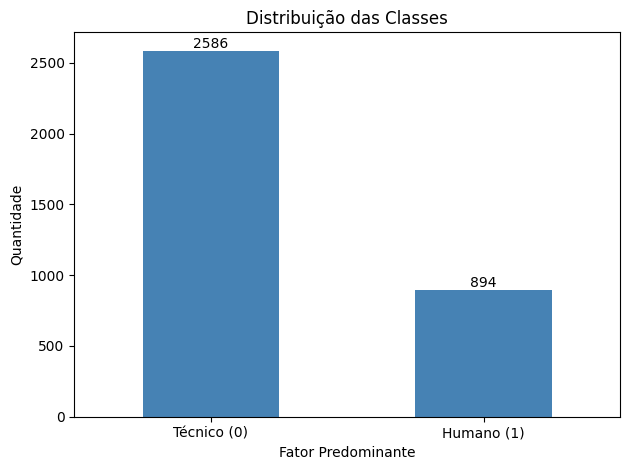

In [18]:
counts = df["fator_predominante"].value_counts().sort_index()

ax = counts.plot(kind="bar", color="steelblue")
ax.set_xticklabels(["Técnico (0)", "Humano (1)"], rotation=0)
ax.set_title("Distribuição das Classes")
ax.set_xlabel("Fator Predominante")
ax.set_ylabel("Quantidade")

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Distribuição das Classes

Após a criação e filtragem do target, o dataset ficou com 2.586 registros classificados como `Técnico` (0) e 894 como `Humano` (1), totalizando 3.480 registros. Os 1.728 registros classificados como `Outros` foram descartados por não se enquadrarem em nenhuma das duas categorias de interesse. A proporção entre as classes é de 74.3% `Técnico` e 25.7% `Humano`, caracterizando um desbalanceamento moderado. Um modelo treinado diretamente nesses dados tenderia a prever `Técnico` na maioria dos casos, atingindo aproximadamente 74% de acurácia sem aprender nada sobre a classe `Humano`, que é justamente a classe de maior interesse para o objetivo do projeto. Esse desbalanceamento será tratado na seção de Balanceamento de Classes através do SMOTE, aplicado exclusivamente nos dados de treino após o split, preservando a distribuição real nos dados de teste.

# Separação de Features, Target e Split


In [19]:

X = df.drop(columns=["fator_predominante"])
y = df["fator_predominante"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")

Treino: 2784 registros
Teste: 696 registros


### Separação de Features, Target e Split

O dataset foi dividido em 80% para treino (2.784 registros) e 20% para teste (696 registros). O parâmetro `stratify=y` garante que a proporção entre as classes seja preservada em ambos os conjuntos, com 74.3% `Técnico` e 25.7% `Humano` tanto no treino quanto no teste.

O parâmetro `random_state=42` garante que a divisão seja reproduzível, com isso qualquer execução do notebook produzirá exatamente os mesmos conjuntos de treino e teste.

# Encoding de Variáveis Categóricas

In [20]:

categorical_cols = ["classificacao", "uf", "periodo_dia"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_cols), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), X_test_encoded], axis=1)

print(f"Features após encoding: {X_train.shape[1]}")
X_train.head()

Features após encoding: 39


,total_aeronaves,saida_pista,mes_sin,mes_cos,classificacao_ACIDENTE,classificacao_INCIDENTE,classificacao_INCIDENTE GRAVE,uf_***,uf_AC,uf_AL,...,uf_RR,uf_RS,uf_SC,uf_SE,uf_SP,uf_TO,periodo_dia_Madrugada,periodo_dia_Manha,periodo_dia_Noite,periodo_dia_Tarde
1057,1,0,5.000000e-01,8.660254e-01,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
936,1,0,8.660254e-01,-5.000000e-01,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3584,1,0,-1.000000e+00,-1.836970e-16,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3523,1,0,5.000000e-01,-8.660254e-01,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2519,1,0,1.224647e-16,-1.000000e+00,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### Encoding de Variáveis Categóricas

As colunas `classificacao`, `uf` e `periodo_dia` são variáveis categóricas sem ordem matemática entre si. Para que os modelos possam processá-las, cada categoria foi transformada em uma coluna binária independente através do `OneHotEncoder`. O encoder aprende as categorias existentes a partir dos dados de treino (`fit_transform`) e aplica 
a mesma transformação nos dados de teste (`transform`), sem aprender nada novo a partir deles. As colunas categóricas originais são removidas e substituídas pelas colunas binárias geradas.

### Decisão: drop='first' não utilizado

O `OneHotEncoder` foi aplicado sem `drop='first'` por três razões. A `LogisticRegression` do sklearn aplica regularização L2 por padrão, mitigando os efeitos da multicolinearidade sem necessidade de remoção manual de colunas. `DecisionTreeClassifier` e `RandomForestClassifier` são imunes a multicolinearidade por natureza. Por fim, a 
combinação de `handle_unknown='ignore'` com `drop='first'` introduz ambiguidade entre categoria desconhecida e categoria removida, o que é indesejável para um dataset com alta cardinalidade em `uf`.

### Decisão: handle_unknown='ignore' sem categoria explícita de desconhecido

O `OneHotEncoder` foi configurado com `handle_unknown='ignore'`, o que significa que categorias desconhecidas no teste resultam em todas as colunas daquela feature zeradas. Uma alternativa seria adicionar uma categoria explícita `"DESCONHECIDO"` antes do encoding, eliminando a ambiguidade entre "categoria desconhecida" e "nenhuma categoria 
ativa". Essa abordagem foi descartada porque as três colunas categóricas do modelo têm domínios fixos e finitos: `uf` cobre os 27 estados brasileiros, `classificacao` possui apenas 3 valores possíveis, e `periodo_dia` possui 4 valores definidos explicitamente neste projeto. Com `stratify=y` no split e 3.480 registros no dataset filtrado, a probabilidade de uma categoria presente no treino não aparecer no teste é desprezível.

`handle_unknown='ignore'` é suficiente para este contexto acadêmico. A adição de categoria explícita seria a abordagem correta em um modelo em produção recebendo dados novos continuamente, por exemplo, se o dataset fosse expandido com ocorrências de novos aeródromos ou categorias operacionais não presentes no dataset original.

# Balanceamento de Classes

In [22]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Após o SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Antes do SMOTE: {0: 2069, 1: 715}
Após o SMOTE: {0: 2069, 1: 2069}


### Balanceamento de Classes com SMOTE

O SMOTE foi aplicado exclusivamente nos dados de treino após o split, preservando a distribuição real nos dados de teste.

Antes do SMOTE, o treino continha 2.069 registros `Técnico` (0) e 715 registros `Humano` (1), mantendo o desbalanceamento de aproximadamente 74%/26% identificado na análise exploratória. Após o SMOTE, ambas as classes ficaram com 2.069 registros, totalizando 4.138 registros de treino balanceados.

O SMOTE não cria cópias dos registros existentes, ele gera exemplos sintéticos da classe minoritária por interpolação entre registros reais vizinhos. Isso expõe o modelo a uma variedade maior de casos `Humano` durante o treinamento, reduzindo o viés em direção à classe majoritária sem duplicar informação.

Os dados de teste permanecem com a distribuição original (desbalanceada), pois eles simulam a distribuição real do dataset(74.3% `Técnico` e 25.7% `Humano`). Avaliar o modelo nessa distribuição garante que as métricas reflitam o desempenho real, sem distorções causadas por um balanceamento artificial no teste.

# Treinamento dos modelos

In [23]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"{name} treinado.")

Decision Tree treinado.
Logistic Regression treinado.
Random Forest treinado.


### Escolha e Justificativa dos Modelos

O objetivo do projeto é classificar ocorrências de aviação civil como fator humano ou técnico com base em variáveis operacionais e contextuais. Para isso, três modelos foram selecionados com propósitos complementares.

A `DecisionTreeClassifier` foi escolhida por sua capacidade de capturar relações não-lineares entre as features sem assumir estrutura matemática prévia, e por ser altamente interpretável, as regras aprendidas podem ser visualizadas e explicadas diretamente. Neste projeto, ela serve como referência para avaliar o ganho obtido com modelos mais complexos.

A `RandomForestClassifier` foi escolhida como evolução natural da árvore de decisão. Ao combinar múltiplas árvores treinadas em subconjuntos aleatórios dos dados e features, ela reduz o overfitting ao qual a árvore isolada está sujeita. Para um problema com variáveis categóricas de alta cardinalidade como `uf`, esse comportamento ensemble 
tende a produzir classificações mais robustas e generalizáveis.

A `LogisticRegression` foi escolhida como baseline linear e por sua interpretabilidade. Como modelo linear, ela estima a probabilidade de cada classe a partir de uma combinação ponderada das features, pois se performar bem, indica que as relações entre as features e o target têm componente linear relevante. Seus coeficientes permitem identificar quais 
features têm maior influência na distinção entre fator humano e técnico, o que é relevante para o objetivo analítico do projeto.

Todos os modelos foram treinados com hiperparâmetros padrão do sklearn e `random_state=42`, permitindo uma comparação justa sem viés de tuning. A `LogisticRegression` recebeu `max_iter=1000` para garantir convergência, já que o padrão de 100 iterações é insuficiente para datasets com múltiplas features categóricas encodadas.

# Avaliação dos Modelos

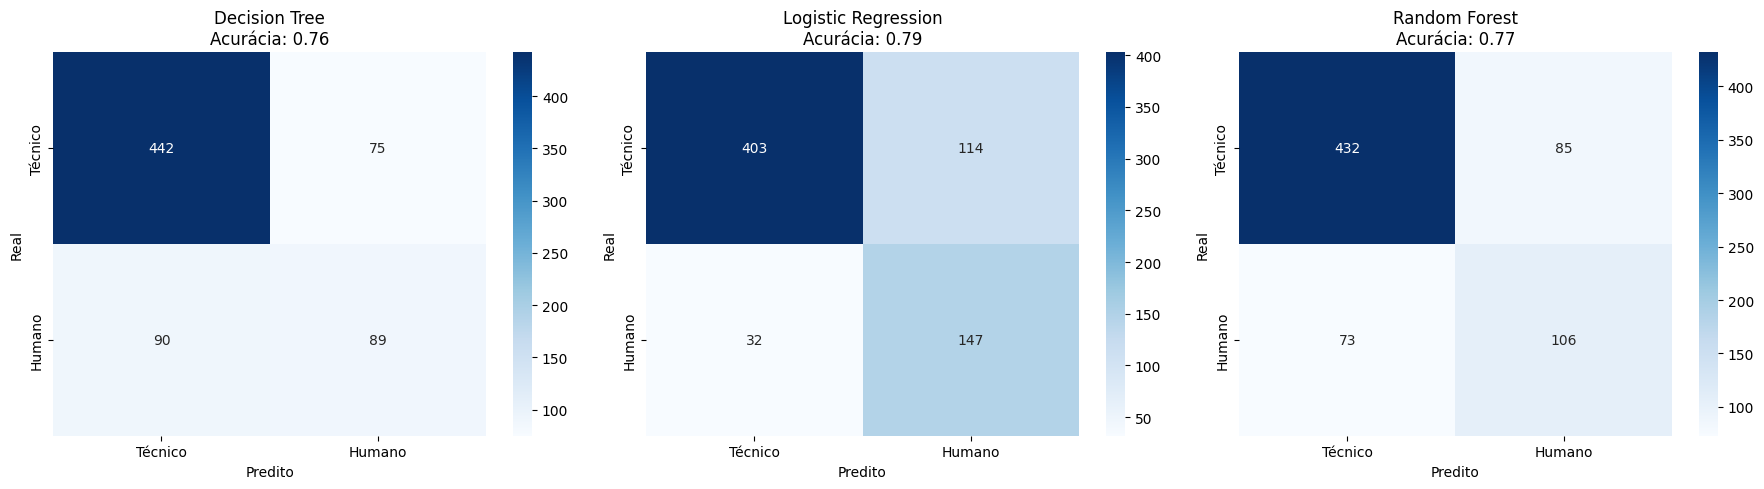

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
accuracies = {}

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", ax=ax, cmap="Blues",
        xticklabels=["Técnico", "Humano"],
        yticklabels=["Técnico", "Humano"]
    )
    ax.set_title(f"{name}\nAcurácia: {acc:.2f}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

#### Interpretando as Matrizes de Confusão

Cada matriz de confusão mostra quatro valores:

- **Técnico predito como Técnico (verdadeiro negativo):** acertos na classe majoritária
- **Técnico predito como Humano (falso positivo):** ocorrências técnicas classificadas erroneamente como humanas
- **Humano predito como Técnico (falso negativo):** ocorrências humanas classificadas erroneamente como técnicas
- **Humano predito como Humano (verdadeiro positivo):** acertos na classe minoritária

Para o objetivo do projeto identificar fatores humanos em acidentes aéreos, o **falso negativo** é o erro mais crítico. Classificar uma ocorrência de causa humana como técnica significa deixar de identificar um fator que poderia ser prevenido com intervenção humana.

---

#### Decision Tree (Acurácia: 0.76)

Acertou 442 de 517 ocorrências técnicas e 89 de 179 humanas. Cometeu 90 falsos negativos o maior número entre os três modelos e 75 falsos positivos. O modelo identifica bem a classe majoritária mas falha de forma expressiva na classe de maior interesse para o projeto.

#### Logistic Regression (Acurácia: 0.79)

Acertou 403 de 517 técnicos e 147 de 179 humanos. Com apenas 32 falsos negativos menos da metade que os outros dois modelos apresentou a melhor capacidade de identificar corretamente casos humanos. O trade-off são 114 falsos positivos, indicando que ela também classifica mais ocorrências técnicas como humanas. Para o contexto de segurança aérea esse trade-off é aceitável é preferível investigar um caso técnico suspeito do que deixar um caso humano sem identificação.

#### Random Forest (Acurácia: 0.77)

Acertou 432 de 517 técnicos e 106 de 179 humanos, com 73 falsos negativos e 85 falsos positivos. Desempenho intermediário entre os dois modelos anteriores mais robusta que a Decision Tree isolada pelo mecanismo de ensemble, mas com número de falsos negativos ainda significativo para o objetivo do projeto.

---

#### Observação

A acurácia geral similar entre os três modelos (0.76, 0.79 e 0.77) pode sugerir desempenho equivalente. No entanto, as matrizes de confusão revelam diferenças relevantes na capacidade de identificar a classe de maior interesse. A análise detalhada das métricas por classe precision, recall e F1-score é apresentada na seção seguinte.

# Relatório de Classificação

Support — Técnico: 517 | Humano: 179

  Decision Tree
  Macro avg — Precision: 0.69 | Recall: 0.68 | F1: 0.68
  Weighted  — Precision: 0.76 | Recall: 0.76 | F1: 0.76

  Logistic Regression
  Macro avg — Precision: 0.74 | Recall: 0.80 | F1: 0.76
  Weighted  — Precision: 0.83 | Recall: 0.79 | F1: 0.80

  Random Forest
  Macro avg — Precision: 0.71 | Recall: 0.71 | F1: 0.71
  Weighted  — Precision: 0.78 | Recall: 0.77 | F1: 0.78



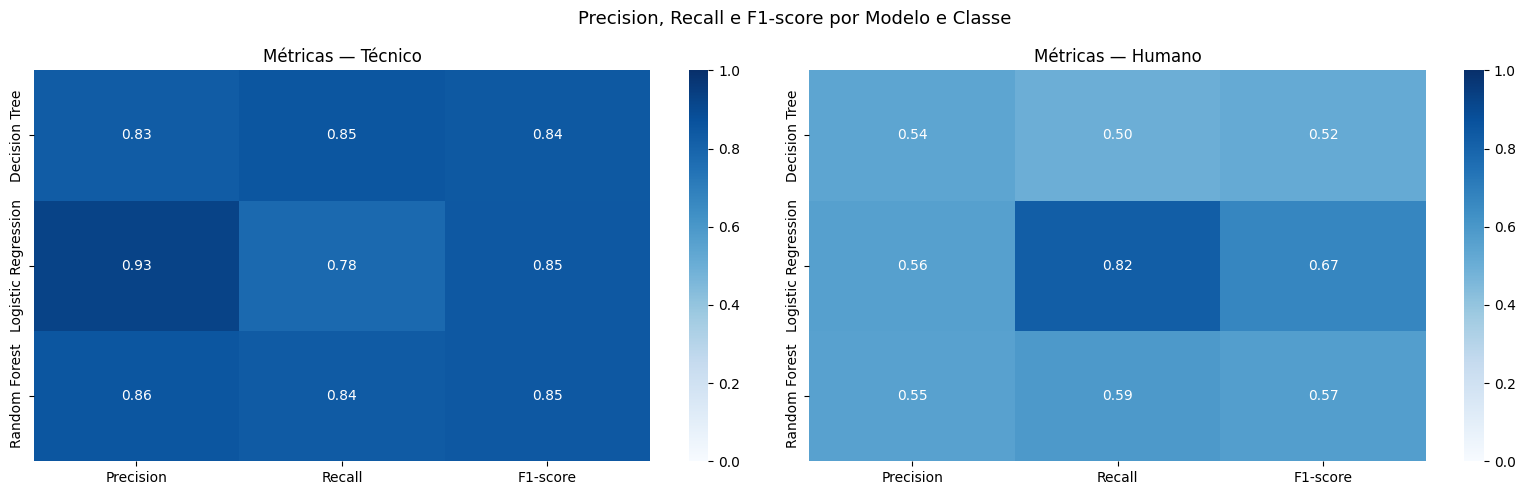

In [32]:
first_model = list(trained_models.values())[0]
first_pred = first_model.predict(X_test)
first_report = classification_report(y_test, first_pred, target_names=["Técnico", "Humano"], output_dict=True)
print(f"Support — Técnico: {int(first_report['Técnico']['support'])} | Humano: {int(first_report['Humano']['support'])}")
print()

metrics_data = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=["Técnico", "Humano"], output_dict=True)

    for classe in ["Técnico", "Humano"]:
        metrics_data.append({
            "Modelo": name,
            "Classe": classe,
            "Precision": report[classe]["precision"],
            "Recall": report[classe]["recall"],
            "F1-score": report[classe]["f1-score"]
        })

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Macro avg — Precision: {report['macro avg']['precision']:.2f} | Recall: {report['macro avg']['recall']:.2f} | F1: {report['macro avg']['f1-score']:.2f}")
    print(f"  Weighted  — Precision: {report['weighted avg']['precision']:.2f} | Recall: {report['weighted avg']['recall']:.2f} | F1: {report['weighted avg']['f1-score']:.2f}")
    print()

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, classe in zip(axes, ["Técnico", "Humano"]):
    subset = metrics_df[metrics_df["Classe"] == classe].set_index("Modelo")[["Precision", "Recall", "F1-score"]]
    sns.heatmap(subset, annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=0, vmax=1)
    ax.set_title(f"Métricas — {classe}")
    ax.set_ylabel("")

plt.suptitle("Precision, Recall e F1-score por Modelo e Classe", fontsize=13)
plt.tight_layout()
plt.show()

### Relatório de Classificação

#### Métricas/dados avaliadas

**Precision:** de todos os casos que o modelo classificou como `Humano`, quantos realmente eram `Humano`. Uma precision baixa significa muitos falsos positivos o modelo está sendo generoso ao classificar como humano.

**Recall:** de todos os casos que realmente eram `Humano`, quantos o modelo identificou corretamente. Um recall baixo significa muitos falsos negativos o modelo está deixando casos humanos passarem como técnicos.

**F1-score:** média harmônica entre precision e recall. Útil quando há desbalanceamento entre as classes, pois penaliza modelos que sacrificam muito uma métrica para ganhar na outra.

**Macro avg:** média simples das métricas entre as classes, tratando `Técnico` e `Humano` com peso igual independente do número de ocorrências de cada uma. É a métrica mais relevante para avaliar o desempenho em um problema desbalanceado, pois expõe quando um modelo performa bem na classe majoritária mas falha na minoritária.

**Weighted avg:** média das métricas ponderada pelo número de ocorrências de cada classe (`support`). Dá mais peso à classe majoritária (`Técnico`) por ela ter mais registros no teste. Tende a ser mais otimista que a macro avg em datasets desbalanceados e por isso dai ser interpretada com cautela neste projeto.

**Support:** número real de ocorrências de cada classe no conjunto de teste, refletindo o desbalanceamento original preservado pelo `stratify=y`.

---

#### Decision Tree

| | Precision | Recall | F1-score |
|---|---|---|---|
| Técnico | 0.83 | 0.85 | 0.84 |
| Humano | 0.54 | 0.50 | 0.52 |

A Decision Tree apresentou o pior desempenho na classe `Humano`. O recall de 0.50 
indica que o modelo identificou corretamente apenas metade dos casos humanos. O F1-score de 0.52 para `Humano` reflete o desequilíbrio entre as classes o modelo performa bem para `Técnico` (F1 0.84) mas falha na classe de maior interesse. A macro avg de 0.68 expõe esse desequilíbrio mais claramente que a acurácia de 0.76.

---

#### Logistic Regression

| | Precision | Recall | F1-score |
|---|---|---|---|
| Técnico | 0.93 | 0.78 | 0.85 |
| Humano | 0.56 | 0.82 | 0.67 |

A Regressão Logística apresentou o melhor recall para `Humano` (0.82) identifica corretamente 82% dos casos humanos. O trade-off é uma precision de 0.56 indicando que parte das classificações como `Humano` são na verdade casos técnicos. O F1-score de 0.67 para `Humano` é o mais alto entre os três modelos e a macro avg de 0.76 indica o melhor equilíbrio geral entre as classes.

---

#### Random Forest

| | Precision | Recall | F1-score |
|---|---|---|---|
| Técnico | 0.86 | 0.84 | 0.85 |
| Humano | 0.55 | 0.59 | 0.57 |

A Random Forest ficou entre os dois modelos em todas as métricas para `Humano`. O recall de 0.59 é superior à Decision Tree (0.50) mas inferior à Regressão Logística (0.82). A macro avg de 0.71 confirma desempenho intermediário.

---

#### Conclusão

| Modelo | F1 Técnico | F1 Humano | Macro avg |
|---|---|---|---|
| Decision Tree | 0.84 | 0.52 | 0.68 |
| Logistic Regression | 0.85 | 0.67 | 0.76 |
| Random Forest | 0.85 | 0.57 | 0.71 |

A **Regressão Logística** apresentou o maior F1-score para `Humano` (0.67), o maior recall (0.82) e a maior macro avg (0.76), sendo a mais adequada para o objetivo específico deste projeto minimizar casos humanos classificados erroneamente como técnicos.

Vale ressaltar que essa conclusão é válida para este dataset e pipeline específicos. A Regressão Logística captura apenas relações lineares entre as features e o target. Modelos de árvore são capazes de capturar relações não lineares e interações complexas que a Regressão Logística não representa o que em tese os tornaria mais adequados para um problema com variáveis categóricas de alta cardinalidade como `uf`.

Há um fator estrutural no pipeline que pode estar favorecendo a Regressão Logística de forma desproporcional que é que o SMOTE gera exemplos sintéticos por interpolação linear entre vizinhos existentes. Os exemplos sintéticos de `Humano` adicionados ao treino são combinações lineares de exemplos reais introduzindo uma estrutura parcialmente linear nos dados balanceados por construção. A Regressão Logística pode estar se beneficiando dessa característica de forma que os modelos de árvore não se beneficiam na mesma proporção. Em um dataset maior com mais registros reais da classe `Humano` e sem necessidade de geração sintética modelos de árvore tenderiam a capturar padrões que a Regressão Logística não conseguiria representar possivelmente invertendo o resultado observado.

# Importância das Features

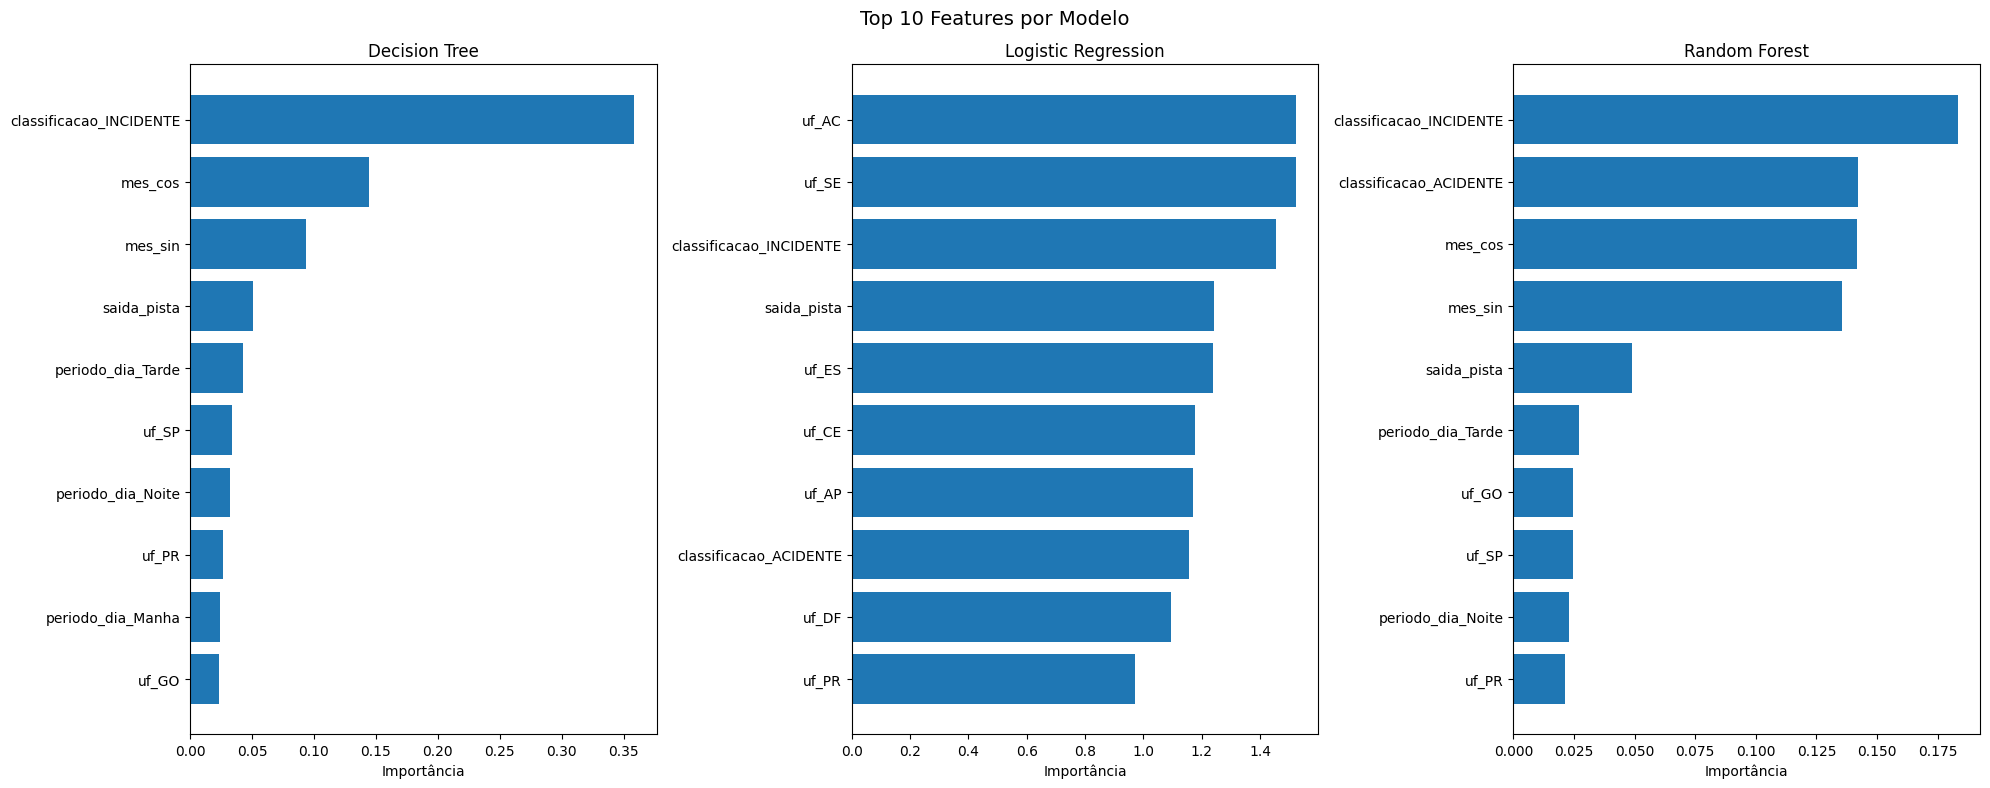

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, (name, model) in zip(axes, trained_models.items()):
    feature_names = X_train.columns.tolist()
    
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(10)
    
    ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
    ax.set_title(f"{name}")
    ax.set_xlabel("Importância")

plt.suptitle("Top 10 Features por Modelo", fontsize=14)
plt.tight_layout()
plt.show()

### Análise de Importância das Features por Modelo

#### Decision Tree

A `classificacao_INCIDENTE` foi a feature mais relevante (0.36), respondendo por mais de um terço da importância total. A árvore encontrou na classificação da ocorrência o critério mais discriminante para separar fator humano de técnico. As variáveis temporais `mes_cos` (0.14) e `mes_sin` (0.09) ocuparam segundo e terceiro lugar, confirmando que o mês captura padrões sazonais relevantes. `saida_pista` (0.05) também contribuiu saída de pista é frequentemente associada a erros de pilotagem. Entre as features de localização, `uf_SP` e `uf_PR` tiveram maior peso, possivelmente 
pelo alto volume de ocorrências nesses estados.

#### Logistic Regression

O comportamento da Regressão Logística foi distinto dos modelos de árvore. Os coeficientes mais altos foram de estados específicos `uf_AC` (1.52), `uf_SE` (1.52) e `uf_ES` (1.24). Isso indica que a Regressão Logística encontrou padrões geográficos fortes na separação das classes determinados estados têm associação linear mais clara com um tipo específico de fator. Esse comportamento é consistente com o raciocínio apresentado na seção anterior a Regressão Logística busca fronteiras lineares e estados com distribuição de causas mais polarizada oferecem separação linear mais nítida. `classificacao_INCIDENTE` (1.45) e `saida_pista` (1.24) também aparecem com alto peso, sendo consistentes com os modelos de árvore.

Vale notar que os coeficientes da Regressão Logística representam o peso linear de cada feature na probabilidade de classificação enquanto os valores de `feature_importances_` das árvores representam redução de impureza. Os valores não são diretamente comparáveis entre modelos mas a direção das features mais relevantes pode ser comparada.

#### Random Forest

A Random Forest apresentou a distribuição de importância mais equilibrada. `classificacao_INCIDENTE` (0.18) e `classificacao_ACIDENTE` (0.14) aparecem juntas no topo o ensemble considera a classificação da ocorrência como um todo mais relevante do que uma categoria isolada. As variáveis temporais `mes_cos` (0.14) e `mes_sin` (0.14) têm pesos praticamente iguais confirmando que o mês captura informação relevante de forma consistente. A distribuição mais uniforme é esperada ao treinar múltiplas árvores em subconjuntos aleatórios de features o ensemble reduz a dominância de uma única feature e distribui o poder preditivo de forma mais equilibrada. Esse comportamento contrasta com a Decision Tree isolada onde uma única feature domina com 0.36 de importância.

---

#### Padrão comum entre os modelos

Três features aparecem consistentemente entre as mais relevantes nos três modelos `classificacao_INCIDENTE`, `mes_cos`/`mes_sin` e `saida_pista`. Isso sugere que

- O tipo de classificação da ocorrência carrega informação discriminante real sobre a causa acidente, incidente e incidente grave têm perfis de causa distintos.
- O mês captura padrões sazonais que influenciam o tipo de causa relacionados ao volume de voos, condições climáticas ou perfil operacional em diferentes períodos do ano.
- A saída de pista tem associação com o tipo de causa coerente com a natureza do problema já que saídas de pista estão frequentemente ligadas a erros de pilotagem.

A feature `uf` teve comportamento diferente entre os modelos nas árvores estados de alto volume como `SP` e `PR` e apareceram com peso moderado enquanto na Regressão Logística, estados menores como `AC` e `SE` tiveram os maiores coeficientes. Isso é consistente com a diferença estrutural entre os modelos a Regressão Logística busca os estados onde a separação linear entre as classes é mais pronunciada independente do volume de ocorrências enquanto as árvores tendem a priorizar features com maior cobertura no dataset.

Essa diferença no comportamento da feature `uf` reforça o argumento levantado na seção anterior a Regressão Logística está aproveitando separações lineares específicas no espaço de features que os modelos de árvore não exploram da mesma 
forma, o que contribui para seu melhor recall na classe `Humano` neste pipeline específico.

# Limitações e Trabalhos Futuros

## Limitações

### Qualidade e representatividade das features

O dataset registra predominantemente metadados administrativos das ocorrências como classificação, localização, status de investigação e datas. Variáveis com alto valor preditivo para distinguir fatores humanos de técnicos estão ausentes, como idade e experiência do piloto, horas de voo acumuladas, idade e histórico de manutenção da aeronave, condições meteorológicas detalhadas no momento do evento e fase do voo em que a ocorrência aconteceu. As features utilizadas são proxies indiretas da causa, pois elas capturam parte da informação mas não as causas subjacentes de forma direta.

### Subjetividade na definição do target

A coluna `ocorrencia_tipo_categoria` foi usada para derivar o target `fator_predominante`, mas essa classificação foi definida manualmente com base em critérios subjetivos. Categorias como `COMBUSTÍVEL` e `OPERAÇÕES NO SOLO` foram descartadas por ambiguidade, pois não é possível determinar com certeza, apenas pelo nome da categoria, se a causa foi humana ou técnica. Isso levanta uma questão fundamental: se as próprias categorias do dataset não distinguem claramente entre fator humano e técnico, o target construído a partir delas carrega essa ambiguidade. Um modelo treinado sobre labels subjetivos aprende padrões que refletem as escolhas de classificação, não necessariamente a realidade das causas dos acidentes.

### Features pouco informativas para o objetivo

Mesmo as features mantidas têm limitação informativa para o objetivo específico do projeto. `uf`, `classificacao` e `periodo_dia` capturam contexto operacional mas não causas. `saida_pista` é um evento secundário, não uma causa. `mes_sin` e `mes_cos` capturam sazonalidade mas de forma indireta. Nenhuma feature descreve diretamente o 
comportamento humano ou o estado técnico da aeronave no momento do evento, pois isso que seria o dado realmente relevante para o problema.

### Viés estrutural do SMOTE

O SMOTE gera exemplos sintéticos por interpolação linear entre registros reais da classe minoritária. Isso introduz uma estrutura parcialmente linear nos dados de treino por construção, o que pode favorecer modelos lineares como a Regressão Logística de forma desproporcional. Os resultados obtidos não podem ser interpretados como evidência 
de que modelos lineares são mais adequados para este problema em geral, pois podem ser um artefato do pipeline de balanceamento.

### Ausência de tuning

Os modelos foram treinados com hiperparâmetros padrão do sklearn. Sem uma busca sistemática de hiperparâmetros, não é possível afirmar que os resultados representam o potencial máximo de cada algoritmo. A comparação entre modelos é justa mas não 
otimizada.

---

## Trabalhos Futuros

### Enriquecimento do dataset

A limitação mais crítica do projeto é a ausência de features operacionais relevantes. Um trabalho futuro poderia cruzar o dataset do CENIPA com outras fontes como registros de habilitação de pilotos da ANAC, dados meteorológicos do INMET no momento e local das ocorrências, e histórico de manutenção das aeronaves, para construir um dataset 
com maior profundidade causal.

### Revisão da definição do target

A classificação manual de categorias em `Humano`, `Técnico` e `Outros` poderia ser revisada com base em literatura de segurança aérea ou validada por especialistas do setor. Uma definição mais rigorosa e menos subjetiva do target produziria um modelo com maior validade externa.

### Aplicação de técnicas de balanceamento alternativas

O SMOTE poderia ser substituído ou complementado por técnicas que não introduzem estrutura linear nos dados, como ADASYN (Adaptive Synthetic Sampling) ou técnicas de undersampling da classe majoritária. Comparar os resultados com diferentes estratégias de balanceamento permitiria isolar o efeito do SMOTE nos resultados observados.

### Tuning de hiperparâmetros

Após identificar os algoritmos mais promissores, aplicar `GridSearchCV` ou `RandomizedSearchCV` para otimizar os hiperparâmetros da Random Forest e da Regressão Logística permitiria extrair o desempenho máximo de cada modelo e produzir uma comparação mais definitiva.

### Modelos mais expressivos

Com um dataset mais rico em features operacionais, modelos como XGBoost, LightGBM ou redes neurais poderiam capturar interações complexas entre variáveis que os três modelos avaliados neste projeto não conseguem representar.

# Conclusão

Este projeto aplicou técnicas de aprendizado de máquina para classificar ocorrências de aviação civil brasileira entre fator humano e fator técnico, utilizando dados públicos do CENIPA.

O pipeline construído cobriu desde a análise exploratória e definição do target até o pré-processamento, balanceamento de classes com SMOTE, encoding de variáveis categóricas e treinamento comparativo de três modelos Decision Tree, Logistic Regression e Random Forest. Todas as decisões de modelagem foram documentadas com justificativa explícita, incluindo a ordem correta de aplicação do SMOTE após o split, o uso de OneHotEncoder em vez de LabelEncoder para variáveis categóricas sem ordem matemática, e a codificação cíclica para a variável de mês.

Entre os três modelos avaliados, a Regressão Logística apresentou o melhor desempenho para a classe de maior interesse `Humano`, com recall de 0.82 e F1-score de 0.67, sendo a mais adequada para o objetivo de minimizar casos humanos classificados erroneamente como técnicos. No entanto, esse resultado deve ser interpretado com cautela, pois o SMOTE introduz estrutura linear nos dados de treino por construção, o que pode favorecer modelos lineares de forma desproporcional. Em um dataset com mais registros reais da classe minoritária, modelos de árvore como a Random Forest tenderiam a capturar padrões mais complexos que a Regressão Logística não consegue representar.

A limitação mais relevante do projeto é estrutural o dataset disponível registra metadados administrativos das ocorrências, não as características operacionais que realmente determinam a causa de um acidente aéreo. As features utilizadas são proxies indiretas, e o próprio target foi construído a partir de categorias com algum grau de subjetividade. O modelo deve ser interpretado como uma análise exploratória com os dados disponíveis os resultados acima de 75% de acurácia em um problema binário desbalanceado indicam que existem padrões capturáveis, mas a generalização para casos reais exigiria um dataset com maior profundidade operacional.


O projeto demonstra que é possível identificar correlações estatísticas entre metadados administrativos e o target construído, mas não estabelece relações causais entre as features e as causas reais dos acidentes.